# Word Weight Comparison

This notebook compares the word weights learned by Perceptron, Average Perceptron, and Pegasos on the 3,000-sentence UCI Sentiment Labelled Sentences dataset.

The feature matrix `X` and label vector `y` are kept separate. The general-purpose classifier module receives sparse `(y_i, x_i)` pairs only at the learning boundary.


In [1]:
from pathlib import Path
import random
import re
import sys
import urllib.request
import zipfile
import numpy as np
import matplotlib.pyplot as plt

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name != 'project_1':
    candidate = PROJECT_DIR / 'unit_1' / 'project_1'
    if candidate.exists():
        PROJECT_DIR = candidate
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from linear_classification import average_perceptron, pegasos, perceptron


## Load and vectorize the dataset


In [2]:
DATA_URL = 'https://archive.ics.uci.edu/static/public/331/sentiment+labelled+sentences.zip'
DATA_DIR = PROJECT_DIR / 'data' / 'sentiment_labelled_sentences'
DATA_DIR.mkdir(parents=True, exist_ok=True)
ZIP_PATH = DATA_DIR / 'sentiment_labelled_sentences.zip'
if not ZIP_PATH.exists():
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
with zipfile.ZipFile(ZIP_PATH) as archive:
    archive.extractall(DATA_DIR)
DATASET_ROOT = DATA_DIR / 'sentiment labelled sentences'
SOURCE_FILES = {
    'IMDb': DATASET_ROOT / 'imdb_labelled.txt',
    'Amazon': DATASET_ROOT / 'amazon_cells_labelled.txt',
    'Yelp': DATASET_ROOT / 'yelp_labelled.txt',
}

def read_source(path, source):
    rows = []
    with path.open(encoding='utf-8') as handle:
        for line in handle:
            sentence, label = line.rstrip('\n').rsplit('\t', 1)
            rows.append((1 if label == '1' else -1, sentence, source))
    return rows

reviews = [row for source, path in SOURCE_FILES.items() for row in read_source(path, source)]
rng = random.Random(42)
rng.shuffle(reviews)
train_reviews = reviews[:2100]

TOKEN_RE = re.compile(r"[A-Za-z0-9]+(?:'[A-Za-z0-9]+)?")
def tokenize(text):
    return TOKEN_RE.findall(text.lower())

counts = {}
for _, text, _ in train_reviews:
    for token in set(tokenize(text)):
        counts[token] = counts.get(token, 0) + 1
vocabulary = {word: i for i, word in enumerate(sorted(word for word, count in counts.items() if count >= 2))}

def vectorize(rows):
    X, y = [], []
    for label, text, _ in rows:
        X.append({vocabulary[token]: 1.0 for token in set(tokenize(text)) if token in vocabulary})
        y.append(label)
    return X, np.asarray(y, dtype=int)

X, y = vectorize(train_reviews)
data = list(zip(y, X))
print(f'Training reviews: {len(data)}')
print(f'Vocabulary size: {len(vocabulary)}')


Training reviews: 2100
Vocabulary size: 1752


## Train the three classifiers


In [3]:
EPOCHS = 10
BATCH_SIZE = 32
models = {
    'Perceptron': perceptron(data, epochs=EPOCHS),
    'Average Perceptron': average_perceptron(data, epochs=EPOCHS),
    'Pegasos': pegasos(data, lambda_=1e-3, epochs=EPOCHS, batch_size=BATCH_SIZE, seed=42),
}


## Strongest learned words

A positive weight pushes the score toward the positive class. A negative weight pushes it toward the negative class. The magnitude indicates how strongly the feature contributes to the linear score.


In [4]:
index_to_word = {index: word for word, index in vocabulary.items()}
for name, weights in models.items():
    positive = sorted(((weight, index_to_word[index]) for index, weight in weights.items() if weight > 0), reverse=True)[:15]
    negative = sorted(((weight, index_to_word[index]) for index, weight in weights.items() if weight < 0))[:15]
    print(f'\n{name}')
    print('Strongest positive words:', [(word, round(weight, 4)) for weight, word in positive])
    print('Strongest negative words:', [(word, round(weight, 4)) for weight, word in negative])



Perceptron
Strongest positive words: [('perfect', np.float64(15.0)), ('happier', np.float64(13.0)), ('great', np.float64(11.0)), ('works', np.float64(10.0)), ('15', np.float64(10.0)), ('nice', np.float64(9.0)), ('game', np.float64(9.0)), ('dialing', np.float64(9.0)), ('beautiful', np.float64(9.0)), ('shot', np.float64(8.0)), ('loved', np.float64(8.0)), ('jawbone', np.float64(8.0)), ('fine', np.float64(8.0)), ('excellent', np.float64(8.0)), ('ears', np.float64(8.0))]
Strongest negative words: [('bad', np.float64(-10.0)), ('poor', np.float64(-10.0)), ('hours', np.float64(-9.0)), ('sick', np.float64(-9.0)), ('slow', np.float64(-9.0)), ('sucked', np.float64(-9.0)), ('3', np.float64(-8.0)), ('average', np.float64(-8.0)), ('avoid', np.float64(-8.0)), ('bland', np.float64(-8.0)), ('terrible', np.float64(-8.0)), ('unfortunately', np.float64(-8.0)), ('unhappy', np.float64(-8.0)), ('appalling', np.float64(-7.0)), ('directing', np.float64(-7.0))]

Average Perceptron
Strongest positive words: [('

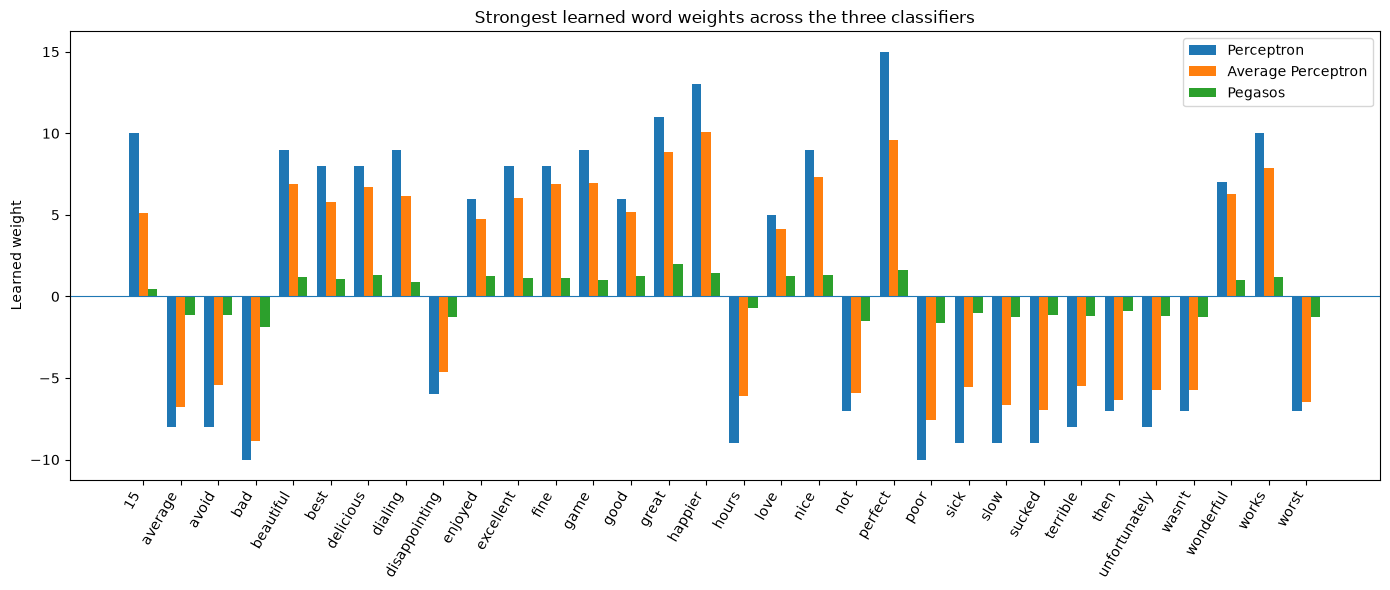

In [5]:
common_words = set()
for weights in models.values():
    top = sorted(weights, key=lambda index: abs(weights[index]), reverse=True)[:20]
    common_words.update(index_to_word[index] for index in top)
words = sorted(common_words)
indices = np.arange(len(words))
width = 0.25
fig, ax = plt.subplots(figsize=(14, 6))
for offset, (name, weights) in zip((-width, 0, width), models.items()):
    ax.bar(indices + offset, [weights.get(vocabulary[word], 0.0) for word in words], width, label=name)
ax.axhline(0, linewidth=0.8)
ax.set_xticks(indices)
ax.set_xticklabels(words, rotation=60, ha='right')
ax.set_ylabel('Learned weight')
ax.set_title('Strongest learned word weights across the three classifiers')
ax.legend()
plt.tight_layout()
plt.show()


## Interpretation

The three classifiers use the same sparse feature representation but different learning rules. Differences in the learned weights therefore illustrate the effect of the optimization method rather than a change in the text representation.

Dataset source: Kotzias et al., **Sentiment Labelled Sentences**, UCI Machine Learning Repository, DOI 10.24432/C57604.
